# **ICS5110 Part 4 - Model Comparitive Analysis**

## Importing packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
import json
from mlxtend.evaluate import mcnemar_table, mcnemar
from itertools import combinations

## **Loading the saved model results from Part 3**

In [2]:
results_paths = {
    "Logistic Regression": "results/log_reg_results.json",
    "Random Forest": "results/random_forest_results.json",
    "Support Vector Machine": "results/support_vector_machine_results_fatal.json",
    "Gradient Boosting": "results/grad_boost_results.json",
}

model_results = {}
for name, path in results_paths.items():
  print(path)
  with open(path, "rb") as f:
      model_results[name] = json.load(f)

log_reg_results.json
random_forest_results.json
support_vector_machine_results_fatal.json
grad_boost_results.json


## **Creating a comprehensive table showcasing the metric results for each model (i.e. accuracy, precision, recall, F1-score)**

In [3]:
log_reg_main_results = model_results['Logistic Regression']['question_4']
random_forest_results = model_results['Random Forest']
support_vector_machine_results = model_results['Support Vector Machine']
grad_boost_results = model_results['Gradient Boosting']

results_dict = {
    'Logistic Regression': log_reg_main_results,
    'Random Forest': random_forest_results,
    'Support Vector Machine': support_vector_machine_results,
    'Gradient Boosting': grad_boost_results
}

In [4]:
def get_metrics(results_data):
  acc = results_data['metric_results']['accuracy']

  macro_avg = results_data['metric_results']['macro avg']
  weighted_avg = results_data['metric_results']['weighted avg']

  macro_prec = macro_avg['precision']
  macro_rec = macro_avg['recall']
  macro_f1 = macro_avg['f1-score']

  weighted_prec = weighted_avg['precision']
  weighted_rec = weighted_avg['recall']
  weighted_f1 = weighted_avg['f1-score']

  neg_class_metrics = results_data['metric_results']['0']
  pos_class_metrics = results_data['metric_results']['1']

  pos_prec = pos_class_metrics['precision']
  pos_rec = pos_class_metrics['recall']
  pos_f1 = pos_class_metrics['f1-score']

  neg_prec = neg_class_metrics['precision']
  neg_rec = neg_class_metrics['recall']
  neg_f1 = neg_class_metrics['f1-score']

  roc_auc = results_data['roc_curve_ovrll']['roc_auc']
  tpr = results_data['roc_curve_ovrll']['tpr']
  fpr = results_data['roc_curve_ovrll']['fpr']

  return {
        'Accuracy': acc,
        'Precision (Macro)': macro_prec,
        'Precision (Weighted)': weighted_prec,
        'Recall (Macro)': macro_rec,
        'Recall (Weighted)': weighted_rec,
        'F1 Score (Macro)': macro_f1,
        'F1 Score (Weighted)': weighted_f1,
        'Precision (Fatal Class)': pos_prec,
        'Precision (Non-Fatal Class)': neg_prec,
        'Recall (Fatal Class)': pos_rec,
        'Recall (Non-Fatal Class)': neg_rec,
        'F1 Score (Fatal Class)': pos_f1,
        'F1 Score (Non-Fatal Class)': neg_f1,
        'ROC AUC': roc_auc,
        'TPR': tpr,
        'FPR': fpr
    }

In [5]:
model_metrics_data = {}

for name, results_path in results_dict.items():
  metrics = get_metrics(results_path)
  model_metrics_data[name] = metrics

# Create a DataFrame from the dictionary of metrics
metrics_df = pd.DataFrame(model_metrics_data).T

metrics_df = metrics_df.drop('TPR', axis=1)
metrics_df = metrics_df.drop('FPR', axis=1)

metrics_df

,Accuracy,Precision (Macro),Precision (Weighted),Recall (Macro),Recall (Weighted),F1 Score (Macro),F1 Score (Weighted),Precision (Fatal Class),Precision (Non-Fatal Class),Recall (Fatal Class),Recall (Non-Fatal Class),F1 Score (Fatal Class),F1 Score (Non-Fatal Class),ROC AUC
Logistic Regression,0.630952,0.494152,0.785993,0.487838,0.630952,0.46276,0.691788,0.111111,0.877193,0.3,0.675676,0.162162,0.763359,0.562162
Random Forest,0.892857,0.746753,0.880334,0.67973,0.892857,0.705493,0.884468,0.571429,0.922078,0.4,0.959459,0.470588,0.940397,0.843919
Support Vector Machine,0.892857,0.628931,0.871743,0.580392,0.892857,0.596154,0.880495,0.333333,0.924528,0.2,0.960784,0.25,0.942308,0.878431
Gradient Boosting,0.904762,0.779605,0.8974,0.72973,0.904762,0.751111,0.900106,0.625,0.934211,0.5,0.959459,0.555556,0.946667,0.836486


## **ROC Curve Plot for all Models**



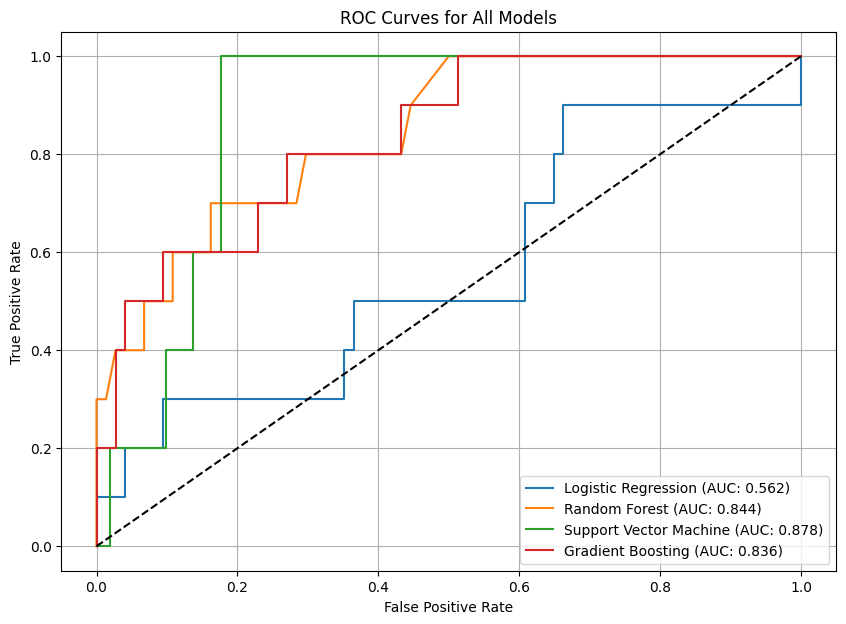

In [6]:
metrics_df = pd.DataFrame(model_metrics_data).T

roc_df = metrics_df[['ROC AUC', 'TPR', 'FPR']]

plt.figure(figsize=(10, 7))

for index, row in roc_df.iterrows():
    plt.plot(row['FPR'], row['TPR'], label=f"{index} (AUC: {row['ROC AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## **Feature Importance Plot for all Models**



In [7]:
def get_imp_features(results_data):
  feature_imp = results_data['model_feature_importances']

  return feature_imp

In [8]:
model_fi_data = {}

for name, results_path in results_dict.items():
  fi_data = get_imp_features(results_path)
  model_fi_data[name] = fi_data

features_list = {}
features_values = {}

for model_name, features in model_fi_data.items():
  features_list[model_name] = []
  features_values[model_name] = []
  for feature in features:
    features_list[model_name].append(list(feature.values())[0])
    features_values[model_name].append(list(feature.values())[1])

In [9]:
model_fi_data['Gradient Boosting']  # FOR TESTING PURPOSES

[{'Feature': 'num__temperature', 'Importance': 0.13552681131913497},
 {'Feature': 'cat__road_type_main road', 'Importance': 0.13427407815142564},
 {'Feature': 'cat__road_type_residential', 'Importance': 0.08793990702921048},
 {'Feature': 'cat__vehicle_involved_motorcycle',
  'Importance': 0.08327323606297664},
 {'Feature': 'num__time_in_hours', 'Importance': 0.07915281604357007},
 {'Feature': 'num__min_age', 'Importance': 0.07410367801730568},
 {'Feature': 'num__rush_hour', 'Importance': 0.06313478421910967},
 {'Feature': 'cat__weekend_weekday_weekend',
  'Importance': 0.06060961489701834},
 {'Feature': 'num__max_age', 'Importance': 0.04976129830009772},
 {'Feature': 'cat__vehicle_involved_car-motorcycle',
  'Importance': 0.045865589112868754},
 {'Feature': 'num__adult_driver_involved', 'Importance': 0.038693415171300975},
 {'Feature': 'cat__vehicle_involved_van-bus',
  'Importance': 0.03019001659295526},
 {'Feature': 'cat__vehicle_involved_car-car',
  'Importance': 0.02919912667837682

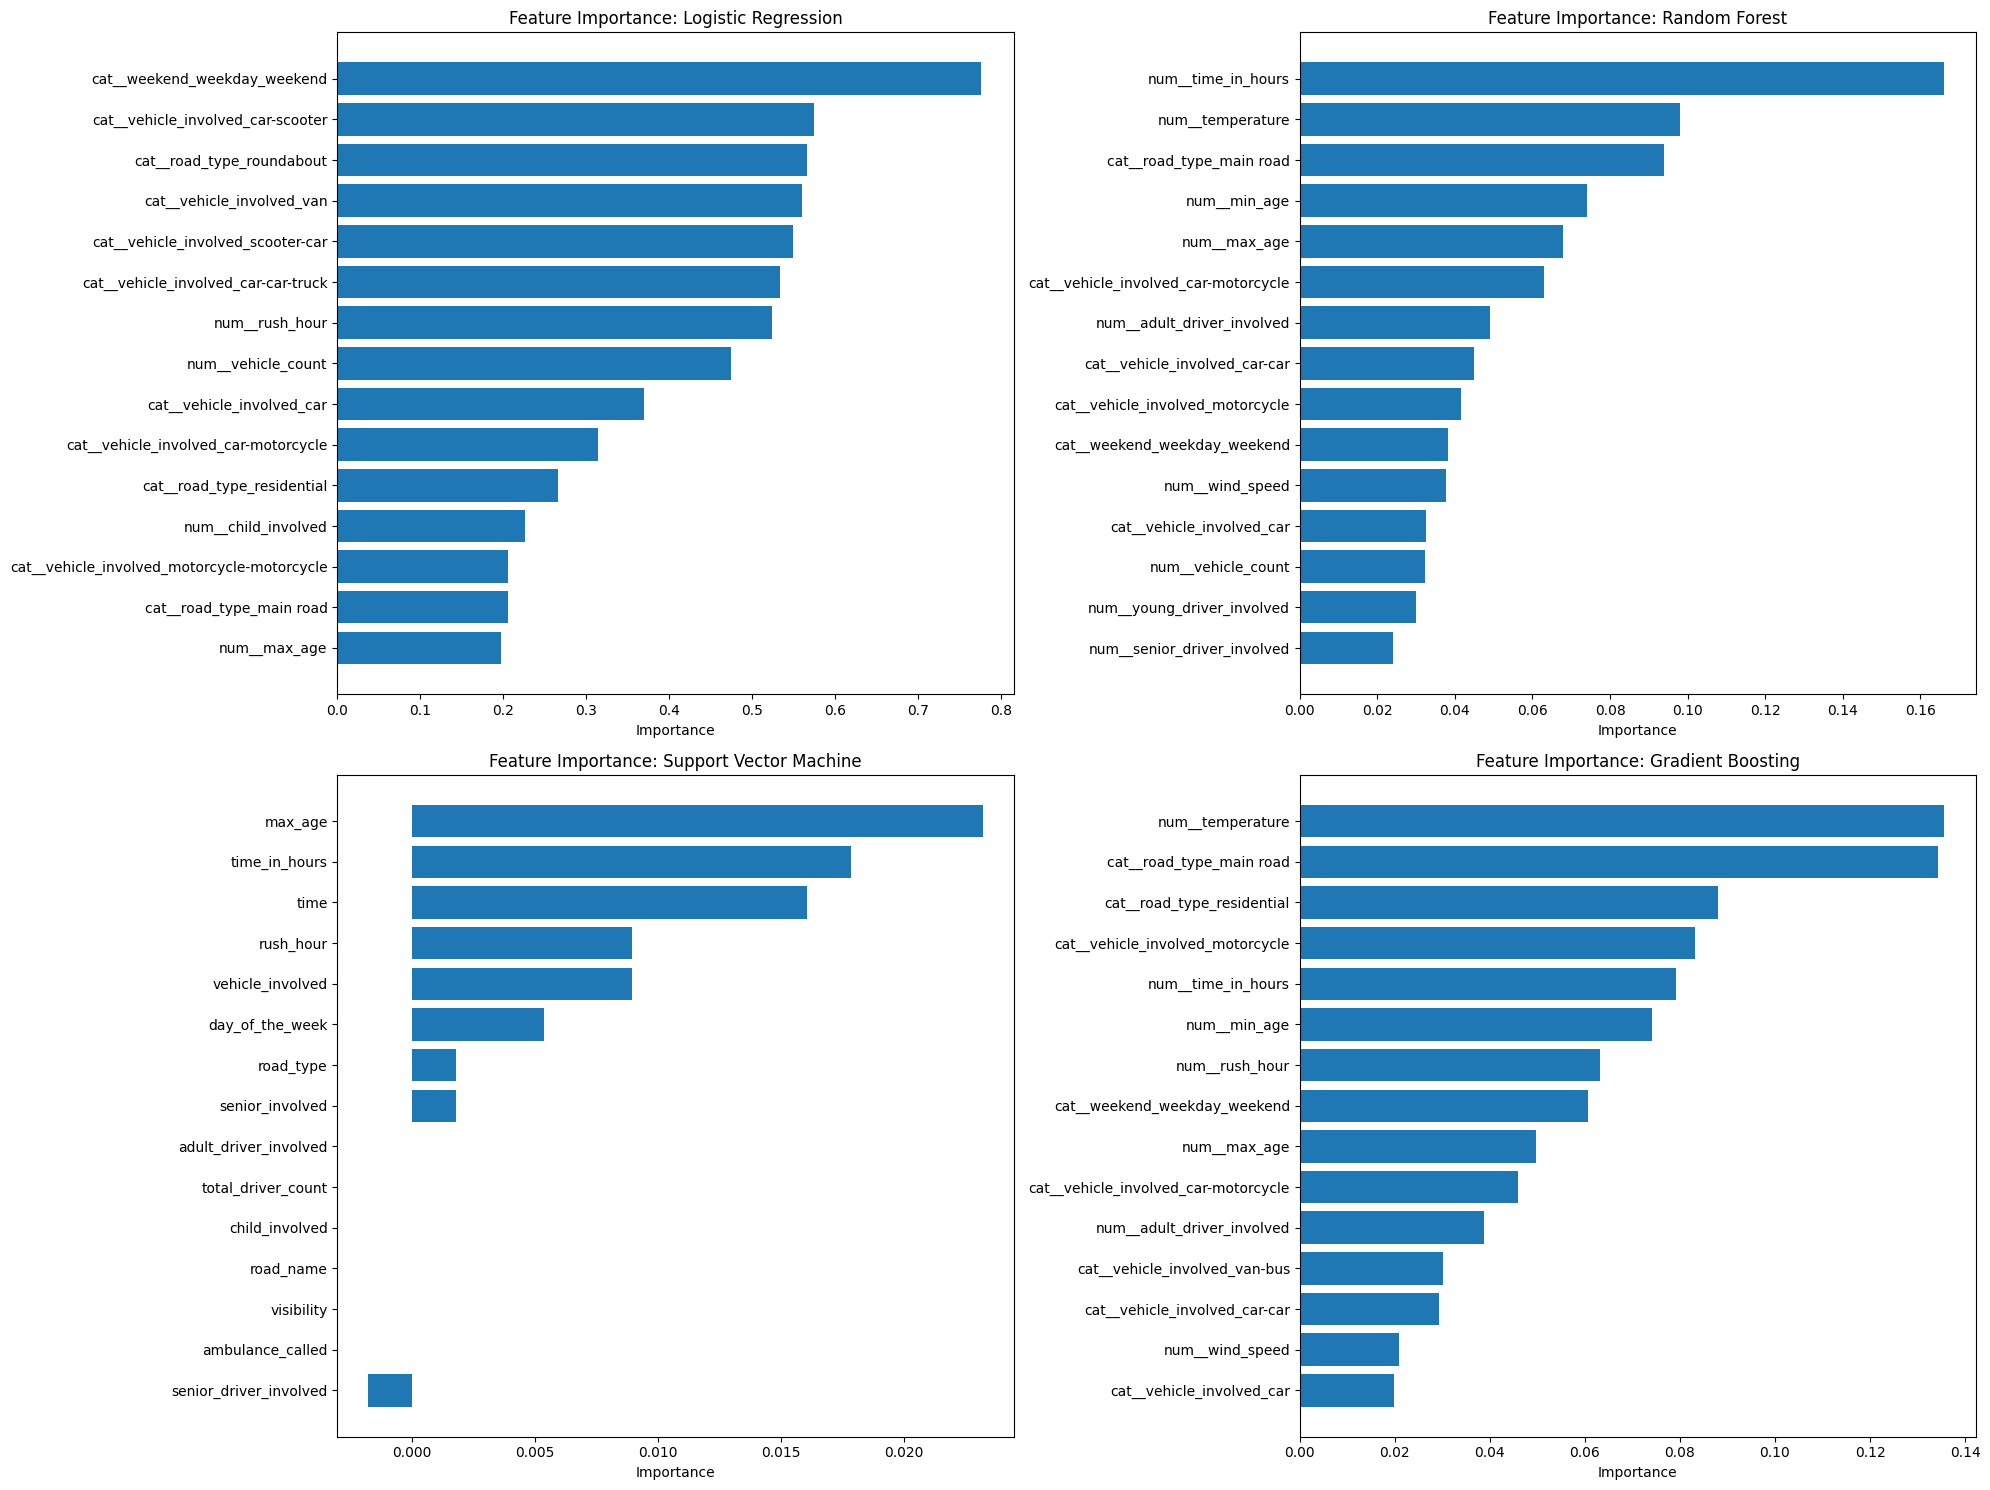

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

for i, (model_name, features) in enumerate(model_fi_data.items()):
    df_features = pd.DataFrame(features)
    if model_name == "Logistic Regression":
        df_features['Odds Ratio_Abs'] = df_features['Odds Ratio'].abs()
        df_features = df_features.sort_values(by='Odds Ratio_Abs', ascending=False)
        top_features_df = df_features.head(15)
        feature_labels = top_features_df['Feature']
        feature_values = top_features_df['Odds Ratio']
    else:
        if 'Importance' in df_features.columns:
            df_features = df_features.sort_values(by='Importance', ascending=False)
            top_features_df = df_features.head(15)
            feature_labels = top_features_df['Feature']
            feature_values = top_features_df['Importance']
        elif 'Coefficient' in df_features.columns:
            df_features['Coefficient_Abs'] = df_features['Coefficient'].abs()
            df_features = df_features.sort_values(by='Coefficient_Abs', ascending=False)
            top_features_df = df_features.head(15)
            feature_labels = top_features_df['Feature']
            feature_values = top_features_df['Coefficient']
        else:
            # Fallback if structure is unexpected
            feature_labels = [list(f.values())[0] for f in features[:15]]
            feature_values = [list(f.values())[1] for f in features[:15]]

    y_pos = np.arange(len(feature_labels))
    axes[i].barh(y_pos, feature_values, align='center')
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(feature_labels)
    axes[i].invert_yaxis()
    axes[i].set_xlabel("Importance")
    axes[i].set_title(f"Feature Importance: {model_name}")

plt.tight_layout()
plt.show()

## **Statistical Significance Testing**

### McNemar's Test

NOTE: Unfortunately, this test could not be perform on the SVM as it had a smaller test set compared to the other approaches.

In [12]:
def highlight_statistical_difference(data):
    # Create a mask of empty strings (no style)
    mask = pd.DataFrame('', index=data.index, columns=data.columns)

    for row in data.index:
        for col in data.columns:
            if row != col:
                if data.loc[row, col] < 0.05:
                    mask.loc[row, col] = 'background-color: #00FF00'
                else:
                    mask.loc[row, col] = 'background-color: transparent'
            else:
                mask.loc[row, col] = 'color: grey'

    return mask

def compute_mcnemar(y_true, y_pred_a, y_pred_b):
    table = mcnemar_table(y_target=np.array(y_true),
                          y_model1=np.array(y_pred_a),
                          y_model2=np.array(y_pred_b))

    chi2, p = mcnemar(ary=table, corrected=True)
    return float(chi2), float(p)

y_true = log_reg_main_results['actual']

# Loading predictions for all models except SVM since it was trained for a different use case
model_y_preds = {model: results_path["predictions"] for model, results_path in results_dict.items() if model != 'Support Vector Machine'}

model_names = list(model_y_preds.keys())
p_matrix = pd.DataFrame(index=model_names, columns=model_names)

for model_a_name, model_a_y in model_y_preds.items():
    for model_b_name, model_b_y in model_y_preds.items():
        if model_a_name == model_b_name:
            p_matrix.loc[model_a_name, model_b_name] = 1.0
            continue
        chi2, p = compute_mcnemar(y_true, model_a_y, model_b_y)
        print(f"Model A: {model_a_name}, Model B: {model_b_name}, p-value: {p}")
        p_matrix.loc[model_a_name, model_b_name] = p

p_matrix.style.apply(highlight_statistical_difference, axis=None).format("{:.4f}").set_caption("P-Values (Green = Significant)")

Model A: Logistic Regression, Model B: Random Forest, p-value: 3.8144777827131e-05
Model A: Logistic Regression, Model B: Gradient Boosting, p-value: 2.2967108733407456e-05
Model A: Random Forest, Model B: Logistic Regression, p-value: 3.8144777827131e-05
Model A: Random Forest, Model B: Gradient Boosting, p-value: 1.0
Model A: Gradient Boosting, Model B: Logistic Regression, p-value: 2.2967108733407456e-05
Model A: Gradient Boosting, Model B: Random Forest, p-value: 1.0


,Logistic Regression,Random Forest,Gradient Boosting
Logistic Regression,1.0000,0.0000,0.0000
Random Forest,0.0000,1.0000,1.0000
Gradient Boosting,0.0000,1.0000,1.0000


### Bootstrap Confidence Intervals

In [13]:
def boot_ci_diff(y_true_a, y_pred_a, y_true_b, y_pred_b, metric, B=5000, seed=0):
    rng = np.random.default_rng(seed)

    y_true_a = np.asarray(y_true_a)
    y_pred_a = np.asarray(y_pred_a)
    y_true_b = np.asarray(y_true_b)
    y_pred_b = np.asarray(y_pred_b)

    da = metric(y_true_a, y_pred_a) - metric(y_true_b, y_pred_b)

    diffs = [metric(y_true_a[rng.integers(len(y_true_a), size=len(y_true_a))], y_pred_a[rng.integers(len(y_pred_a), size=len(y_pred_a))]) -
             metric(y_true_b[rng.integers(len(y_true_b), size=len(y_true_b))], y_pred_b[rng.integers(len(y_pred_b), size=len(y_pred_b))])
             for _ in range(B)]
    diffs = np.asarray(diffs)
    diffs_mean = diffs.mean()
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    p = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    return diffs, diffs_mean, lo, hi, p

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def acc(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

model_y_trues = {model: results_path["actual"] for model, results_path in results_dict.items()}
model_y_preds = {model: results_path["predictions"] for model, results_path in results_dict.items() }

model_names = list(model_y_preds.keys())

for model_a_name, model_b_name in combinations(model_names, 2):
    model_a_y = model_y_trues[model_a_name]
    model_a_p = model_y_preds[model_a_name]
    model_b_y = model_y_trues[model_b_name]
    model_b_p = model_y_preds[model_b_name]
    diff, mean, lo, hi, p = boot_ci_diff(model_a_y, model_a_p, model_b_y, model_b_p, acc)
    print(f"{model_a_name} vs {model_b_name} (Accuracy)", "| Mean Diff = ", mean, "| 95% CI =", (lo, hi), "| P-value = ", p)
    diff, mean, lo, hi, p = boot_ci_diff(model_a_y, model_a_p, model_b_y, model_b_p, f1_macro)
    print(f"{model_a_name} vs {model_b_name} (F1-Macro)", "| Mean Diff = ", mean, "| 95% CI =", (lo, hi), "| P-value = ", p)

Logistic Regression vs Random Forest (Accuracy) | Mean Diff =  -0.18166190476190477 | 95% CI = (np.float64(-0.30952380952380953), np.float64(-0.04761904761904767)) | P-value =  0.0084
Logistic Regression vs Random Forest (F1-Macro) | Mean Diff =  -0.02773519731176682 | 95% CI = (np.float64(-0.18116146044015036), np.float64(0.10921229228339928)) | P-value =  0.718
Logistic Regression vs Support Vector Machine (Accuracy) | Mean Diff =  -0.23281190476190478 | 95% CI = (np.float64(-0.369047619047619), np.float64(-0.10119047619047628)) | P-value =  0.0012
Logistic Regression vs Support Vector Machine (F1-Macro) | Mean Diff =  -0.026000623120995145 | 95% CI = (np.float64(-0.2162843387142453), np.float64(0.10606060606060608)) | P-value =  0.8104
Logistic Regression vs Gradient Boosting (Accuracy) | Mean Diff =  -0.17290238095238097 | 95% CI = (np.float64(-0.30952380952380953), np.float64(-0.0357142857142857)) | P-value =  0.0112
Logistic Regression vs Gradient Boosting (F1-Macro) | Mean Diff 